(03-1-FT-v-praksi)=
# Od Fourierove vrste do DFT: teorija in numerični izračun v praksi

Ta zvezek je **praktični priročnik** za uporabo Fourierove transformacije pri analizi meritev. Osredotoča se na to, **kaj nam rezultati povedo in kako jih pravilno preberemo**.

Rdeča nit: Fourierova vrsta → Fourierova integralna transformacija → DFT v praksi.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fourier_grafi import *

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['font.size'] = 12


---
## 1. del: Fourierova vrsta

Vsak periodičen signal s periodo $T$ lahko zapišemo kot vsoto harmonskih komponent pri frekvencah $f_n = n\,f_0 = n\,\frac{1}{T}$, kjer je $T$ osnovna perioda signala.

:::{note}
$$f(t) = \sum_{n=-\infty}^{\infty} c_n \, e^{\,i 2\pi n f_0 t},
\qquad
c_n = \frac{1}{T}\int_0^T x(t)\, e^{-i 2\pi n f_0 t}\, dt$$

Koeficient $c_n$ je kompleksno število: njegova **amplituda** $|c_n|$ pove amplitudo $n$-tega harmonika, njegov **argument** $\angle c_n$ pa fazo.

**Povezava z realno obliko ($a_n$ in $b_n$)**: 

$$c_n = (a_n - i\,b_n)/2.$$

Kompleksna oblika je kompaktnejša in računsko ugodnejša.

Vsota teče tudi po **negativnih** $n$ - posledica so negativne frekvence pri rezultatu Fourierove transformacije.
:::



### Simetrijske lastnosti

Za **realne** izmerjene signale velja $c_{-n} = c_n^*$, kar pomeni:

| Vrsta signala | Koeficienti $c_n$ |
|---|---|
| Realen, splošen | $c_{-n} = c_n^*$ - amplitudni spekter je simetričen |
| Realen + sod ($\cos \rightarrow a_n$) | $c_n$ so čisto realni |
| Realen + lih ($\sin \rightarrow b_n$) | $c_n$ so čisto imaginarni |

V praksi: ker so vsi izmerjeni signali realni, je amplitudni spekter pri negativnih frekvencah vedno zrcalna kopija pozitivnih. Zato ponavadi prikažemo le **enostranski** spekter.

#### Pripravimo funkcijo za numerični izračun Fourierovih koeficientov

$$c_n = \frac{1}{T}\int_0^T x(t)\, e^{-i 2\pi n f_0 t}\, dt$$

In [2]:
def koeficient_cn(x, t, T, n):
    """n-ti koeficient Fourierove vrste signala x(t) s periodo T."""
    integrand = x * np.exp(-1j * 2 * np.pi * n / T * t)
    return np.trapezoid(integrand, t) / T


#### In še za izračun Fourierove vrste

$$f(t) = \sum_{n=-\infty}^{\infty} c_n \, e^{\,i 2\pi n f_0 t},$$

In [3]:
def vrsta_cn(x, t_perioda, T, n_max):
    """Delna vsota Fourierove vrste s koeficienti c_n do harmonika n_max.
    Vrne realni del; imaginarni del je ~0 za realne signale."""
    
    koeficienti = [koeficient_cn(x, t_perioda, T, n) for n in range(-n_max, n_max+1)]
    eksponenti = [np.exp(1j * 2 * np.pi * n / T * t_perioda) for n in range(-n_max, n_max+1)]
    
    return np.real(np.dot(koeficienti, eksponenti))

:::{admonition} Primer 1.1 - Rekonstrukcija pravokotnega signala s Fourierovo vrsto
:class: seealso

Spodnji pravokotni signal je liha funkcija, koeficienti $c_n$ pa so čisto imaginarni.

Rekonstruiramo ga z vsoto naraščajočega števila harmonikov in opazujemo konvergenco.
:::

In [4]:
T = 1.0
f0 = 1.0 / T

t_perioda = np.linspace(0, T, 500, endpoint=False)
kvadrat_perioda = np.sign(np.sin(2 * np.pi * f0 * t_perioda))

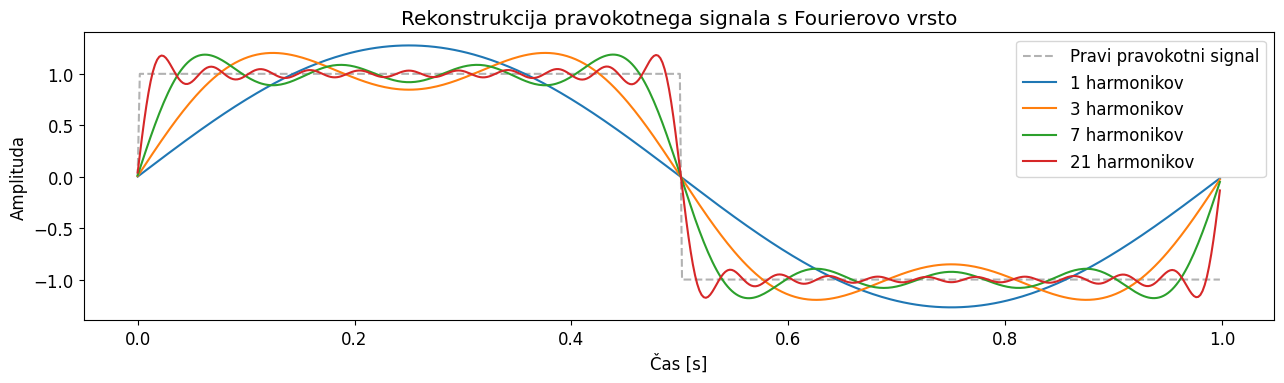

In [5]:
# Rekonstrukcija z različnim številom harmonikov, koeficienti c_n numerično
rekonstrukcije = []
for N_harm in [1, 3, 7, 21]:
    rek = vrsta_cn(kvadrat_perioda, t_perioda, T, N_harm)
    rekonstrukcije.append((f'{N_harm} harmonikov', rek))

plot_cas_primerjava(t_perioda, kvadrat_perioda, rekonstrukcije,
                    ref_label='Pravi pravokotni signal',
                    title='Rekonstrukcija pravokotnega signala s Fourierovo vrsto')
plt.show()


:::{admonition} Primer - Kompleksni koeficienti $c_n$ in negativne frekvence
:class: seealso

Izračunamo in vizualiziramo $c_n$ za pravokotni signal. Pričakujemo:
- Neničelne vrednosti le pri lihih $n$
- Simetričen amplitudni spekter: $|c_{-n}| = |c_n|$
- Čisto imaginarne vrednosti (signal je realen in lih)
:::

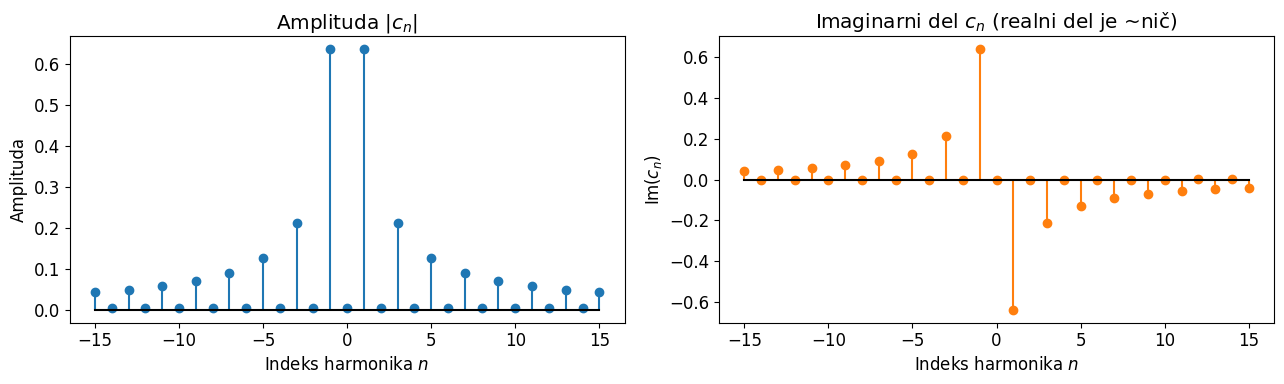

In [6]:
ns = np.arange(-15, 16)
c_n = np.array([koeficient_cn(kvadrat_perioda, t_perioda, T, n) for n in ns])

fig, axes = plt.subplots(1, 2)
ax_spekter(axes[0], ns, np.abs(c_n),
           title='Amplituda $|c_n|$', xlabel='Indeks harmonika $n$')
ax_spekter(axes[1], ns, np.imag(c_n),
           title='Imaginarni del $c_n$ (realni del je ~nič)',
           xlabel='Indeks harmonika $n$', ylabel='Im($c_n$)', color='C1')
plt.tight_layout()
plt.show()


---
## 2. del: Od Fourierove vrste do Fourierove integralne transformacije

Fourierova vrsta velja za **periodične** signale. Realni izmerjeni signali pa splošno niso periodični - nastopijo le za omejen čas. 

**Pustimo $T \to \infty$**: 
* frekvenčni razmik $\Delta f = 1/T \to 0$;
* diskretne frekvence postanejo zvezne;
* vsota harmonikov postane integral.

:::{note}
$$F(f) = \int_{-\infty}^{\infty} x(t)\, e^{-i 2\pi f t}\, dt$$

$F(f)$ je neposredna posplošitev $c_n$ na zvezne frekvence: pove **gostoto harmonične vsebnosti** pri frekvenci $f$.
:::


:::{admonition} Primer: koeficienti `c_n` za pravokoten signal z daljšo periodo $T$
:class: seealso

Sorazmerno z daljšanjem osnovne periode signala se viša frekvenčna ločljivost:

$$ f_n = \frac{n}{T} \Rightarrow \Delta f = \frac{1}{T}$$

Začnemo s prikazom iz prejšnjega primera, namesto indeksa harmonikov označimo frekvence v Hz.
:::

In [7]:
T = 1.0
f0 = 1.0 / T
N_max = 15

t_perioda = np.linspace(0, T, 500, endpoint=False)
kvadrat_perioda = np.sign(np.sin(2 * np.pi * f0 * t_perioda))

In [8]:
ns = np.arange(-N_max, N_max + 1) # Indeksi harmonikov
freq = ns / T # Frekvence harmonikov [Hz]

c_n = np.array([koeficient_cn(kvadrat_perioda, t_perioda, T, n) for n in ns])

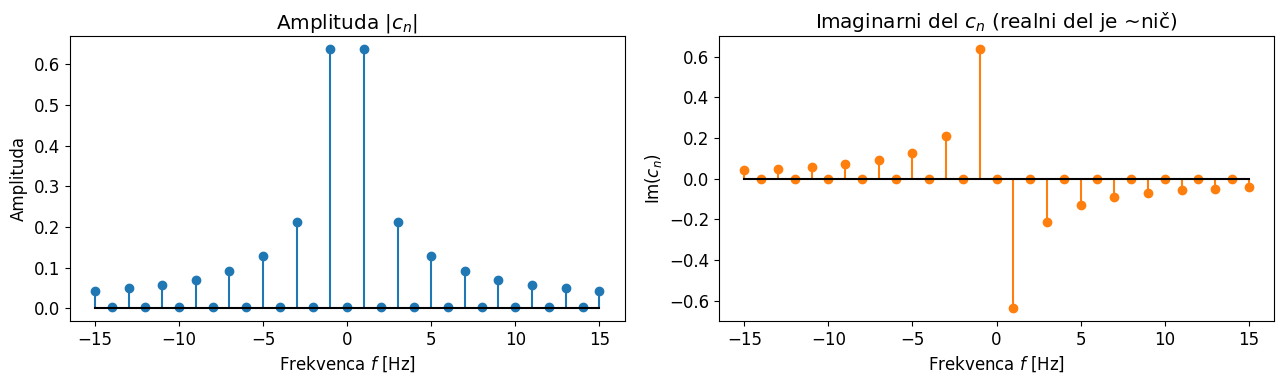

In [9]:
fig, axes = plt.subplots(1, 2)
ax_spekter(axes[0], freq, np.abs(c_n),
           title='Amplituda $|c_n|$', xlabel='Frekvenca $f$ [Hz]')
ax_spekter(axes[1], freq, np.imag(c_n),
           title='Imaginarni del $c_n$ (realni del je ~nič)',
           xlabel='Frekvenca $f$ [Hz]', ylabel='Im($c_n$)', color='C1')
plt.tight_layout()
plt.show()


### Simetrija FT za realne signale

Ker so vsi izmerjeni signali realni, velja za njihov spekter: *vrednost pri frekvenci $-f$ je vedno kompleksno konjugirana vrednosti pri $+f$*:

$$F(-f) = F^*(f).$$

To pomeni, da **amplitudni spekter** $|F(f)|$ vsebuje dvojno informacijo - vrednosti pri pozitivnih in negativnih frekvencah sta identični. 

:::{admonition} Primer - Hermitska simetrija: $F\{\sin(t)\}$ vs $F\{e^{it}\}$
:class: seealso

Prikažemo:
- $\sin(2\pi f_0 t)$ (realen, lih) → imaginaren, lih spekter, simetričen amplitudni spekter
- $e^{i 2\pi f_0 t}$ (kompleksen) → enostranski spekter, brez simetrije
:::

In [10]:
N = 200
fs = 100.0    # frekvenca vzorčenja [Hz]
f0 = 5.0      # frekvenca signala [Hz]
t = np.arange(N) / fs
freq = np.fft.fftfreq(N, 1/fs)

F_realen     = np.fft.fft(np.sin(2 * np.pi * f0 * t))
F_kompleksen = np.fft.fft(np.exp(1j * 2 * np.pi * f0 * t))

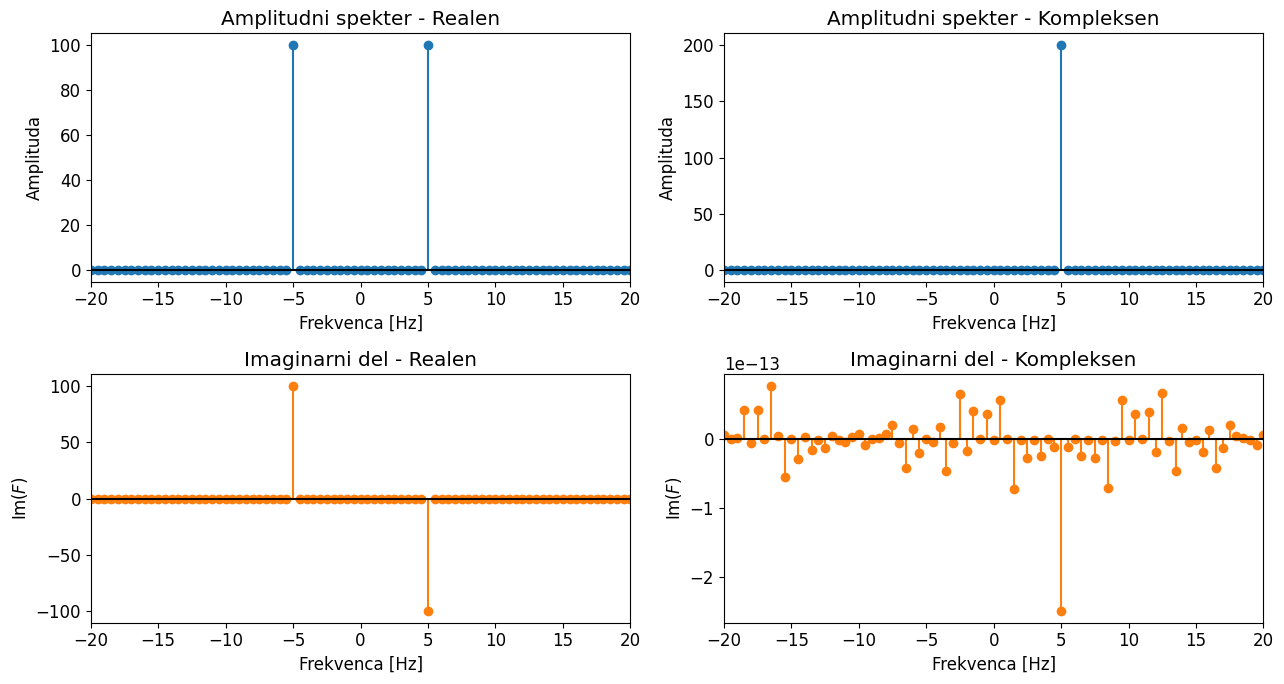

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, (F, oznaka) in enumerate([(F_realen, 'Realen'), (F_kompleksen, 'Kompleksen')]):    
    ax_spekter(axes[0, col], freq, np.abs(F),
               title=f'Amplitudni spekter - {oznaka}', xlim=(-20, 20))
    ax_spekter(axes[1, col], freq, np.imag(F),
               title=f'Imaginarni del - {oznaka}',
               xlim=(-20, 20), ylabel='Im($F$)', color='C1')
plt.tight_layout()
plt.show()

Za analizo realnih signalov torej zadošča enostranski prikaz (pri pozitivnih frekvencah). Tega dobimo z **`np.fft.rfft`**.

In [12]:
F_enostranski = np.fft.rfft(np.sin(2 * np.pi * f0 * t))
freq_enostranski = np.fft.rfftfreq(N, 1/fs)

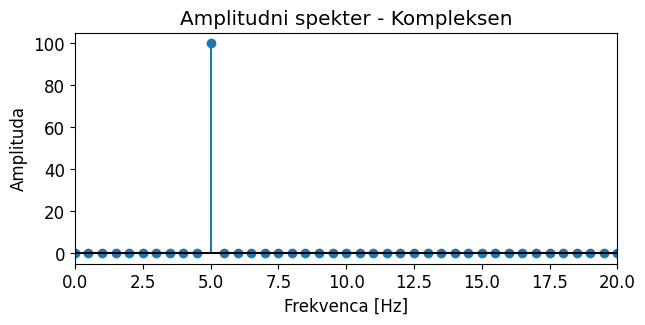

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
ax_spekter(ax, freq_enostranski, np.abs(F_enostranski),
            title=f'Amplitudni spekter - {oznaka}', xlim=(0, 20))

---
## 3. del: Diskretna Fourierova transformacija (DFT)

V praksi imamo vedno opravka z **vzorčenimi, končno dolgimi** signali - temu namenjena DFT.

### Strukturna primerjava

| | Časovna domena | Frekvenčna domena |
|---|---|---|
| **Fourierova vrsta** | Zvezna, periodična | Diskretna |
| **Fourierova transformacija** | Zvezna, aperiodična | Zvezna |
| **DFT** | Diskretna, periodična (predpostavka!) | Diskretna |


Primerjajte DFT z enačbo za $c_n$ iz 1. dela:

:::{note}
$$c_n = \frac{1}{T}\int_0^T x(t)\, e^{-i 2\pi n f_0 t}\, dt
\qquad \longleftrightarrow \qquad
X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-i 2\pi k n / N}$$

Integral postane vsota, zvezni čas $t$ postane diskretni indeks vzorca $n$, normalizacija $1/T$ se prestavi na izhod (ni vgrajena v DFT).

FT je strukturno identična Fourierovi vrsti - to je tudi razlog, zakaj sta si bližje kot DFT in Fourierova integralska transformacija.

DFT obravnava vaših $N$ vzorcev kot **eno periodo** neskončno ponavljajočega se signala. Ta predpostavka periodičnosti ima praktične posledice - gl. razlitje spektra (*spectral leakage*) spodaj.

:::


:::{admonition} Primer - Koeficienti Fourierove vrste in DFT
:class: seealso

Primerjava vrednosti Fourierove vrste z rezultati DFT
:::

In [14]:
# Parametri signala
A = 5.0
f0 = 1.0
T = 1.0 / f0

In [15]:
# Parametri vzorčenja
fs = 20.0
N = 20 # 1 s vzorčenja
t = np.arange(N+1) / fs # Vključimo T, da lahko numerično integriramo celo periodo, kar je pomembno za koeficiente c_n

In [16]:
sig = A * np.sin(2 * np.pi * f0 * t)

Koeficienti Fourierove vrste

In [17]:
N_harmonikov = 10 # 10*f0 = 10 Hz, enako fs/2

c_n = [koeficient_cn(sig, t, T, n) for n in range(-N_harmonikov, N_harmonikov+1)]
freq_cn = np.array([n / T for n in range(-N_harmonikov, N_harmonikov+1)])

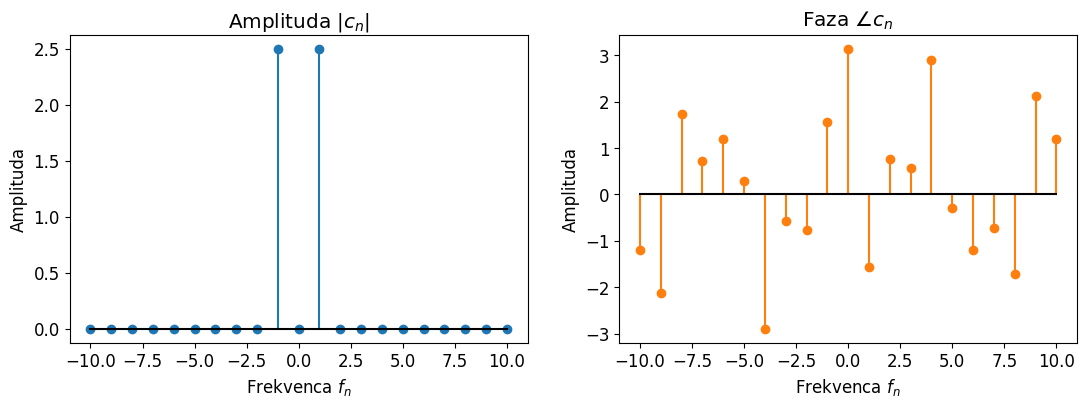

In [18]:
fig, ax = plt.subplots(1, 2)
ax_spekter(ax[0], freq_cn, np.abs(c_n),
           title='Amplituda $|c_n|$', xlabel='Frekvenca $f_n$')
ax_spekter(ax[1], freq_cn, np.angle(c_n), color='C1',
           title='Faza $\\angle c_n$', xlabel='Frekvenca $f_n$')
plt.show()


Rezultat FFT

In [19]:
t = np.arange(N) / fs # Ne vključimo T, kar je bolj primerno za FFT, ki predpostavlja periodičnost signala v vzorčnem intervalu
sig = A * np.sin(2 * np.pi * f0 * t)

In [20]:
F = np.fft.fft(sig) / N # Normiranje komentiramo spodaj
freq = np.fft.fftfreq(N, 1/fs)

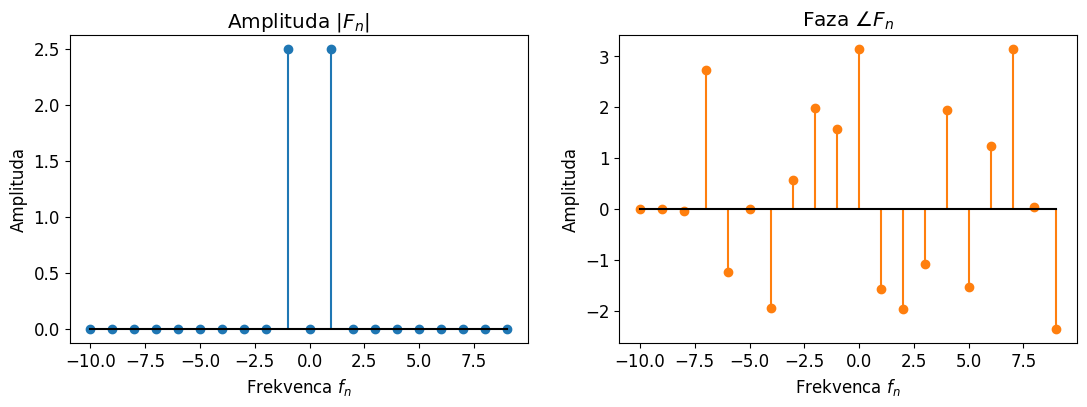

In [21]:
fig, ax = plt.subplots(1, 2)
ax_spekter(ax[0], freq, np.abs(F),
           title='Amplituda $|F_n|$', xlabel='Frekvenca $f_n$')
ax_spekter(ax[1], freq, np.angle(F), color='C1',
           title='Faza $\\angle F_n$', xlabel='Frekvenca $f_n$')
plt.show()

Razlog za razlike v faznih kotih je majhna razlika v časovnih vektorjih + numerična integracija.

In [22]:
freq_cn[11], np.rad2deg(np.angle(c_n)[11])

(np.float64(1.0), np.float64(-90.0))

In [23]:
freq[1], np.rad2deg(np.angle(F)[1])

(np.float64(1.0), np.float64(-90.00000000000001))

### Normiranje: kako iz DFT dobimo fizikalne amplitude

Surovi rezultat `np.fft.fft` ni normiran. Da dobimo fizikalne amplitude, je v rabi:

- **Amplitudno normiranje** (`FFT / N`): 

    $\sin$ z amplitudo $A$ $\rightarrow$ dva vrhova $A/2$ pri $\pm f_0$ 
    
    (skladno z $|c_{\pm n}| = A/2$ iz Fourierove vrste)

- **"Inženirsko" normiranje za realni signal** (`RFFT/ N`, nato `[1:-1] *= 2`): 

    $\sin$ z amplitudo $A$ $\rightarrow$ en vrh $A$ pri $f_0$. 

    Množenje z 2 je utemeljeno s Hermitsko simetrijo: zavržemo simetrične amplitude na negativnem delu frekvenčne osi s tem množenjem ohranimo energijo signala. 
    
    DC ($k=0$) in Nyquist ($k=N/2$) nimata negativnega para, zato teh **ne** množimo.

**Parsevalov teorem** pravi, da mora moč iz spektra ustrezati moči časovnega signala - to je praktičen preizkus pravilnosti normiranja.

$$
\frac{1}{T_p}\int_0^{T_p}x^2(t)\,\textrm{d}t=
\sum_{k=0}^{N-1}X[k]²,
$$

:::{admonition} Primer - Normalizacija in Parsevalov teorem
:class: seealso

Primerjamo obe normalizacijski konvenciji na primeru sinusa z amplitudo $A$ in preverimo Parsevalov teorem za vsako od njiju.
:::

In [24]:
A = 5.0
f0 = 10.0

N = 200
fs = 200
t = np.arange(N) / fs

sig = A * np.sin(2 * np.pi * f0 * t)

In [25]:
F_dvostranski = np.fft.fft(sig) / N
freq_dvostranski = np.fft.fftfreq(N, 1/fs)

In [26]:
F_enostranski = np.fft.rfft(sig) / N
F_enostranski[1:-1] *= 2  # Normiramo enostranski spekter (NE DC, NE Nyquist)
freq_enostranski = np.fft.rfftfreq(N, 1/fs)

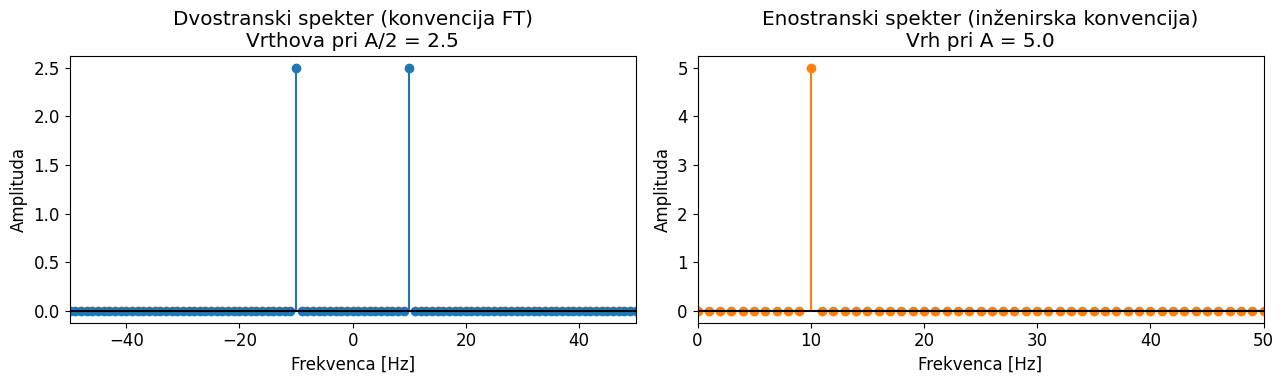

In [27]:
fig, axes = plt.subplots(1, 2)
ax_spekter(axes[0], freq_dvostranski, np.abs(F_dvostranski),
           title=f'Dvostranski spekter (konvencija FT)\nVrthova pri A/2 = {A/2:.1f}',
           xlim=[-50, 50])
ax_spekter(axes[1], freq_enostranski, np.abs(F_enostranski),
           title=f'Enostranski spekter (inženirska konvencija)\nVrh pri A = {A:.1f}',
           xlim=[0, 50], color='C1')
plt.tight_layout()
plt.show()


In [28]:
# Moč v časovni domeni
moc_cas = np.mean(sig**2)
print(f"Moč v časovni domeni: {moc_cas:.4f} (teoretično A^2/2 = {A**2/2:.4f})")

Moč v časovni domeni: 12.5000 (teoretično A^2/2 = 12.5000)


In [29]:
# Dvostranski spekter (konvencija Fourierove transformacije)
F_dvo = np.fft.fft(sig) / N
freq_dvo = np.fft.fftfreq(N, 1/fs)
moc_dvostranski = np.sum(np.abs(F_dvo)**2)
print(f"Moč iz dvostranskega spektra: {moc_dvostranski:.4f} (teoretično A^2/2 = {A**2/2:.4f})")

Moč iz dvostranskega spektra: 12.5000 (teoretično A^2/2 = 12.5000)


In [30]:
# Enostranski spekter 
moc_enostranski = (np.abs(F_enostranski[0])**2
                   + np.sum(np.abs(F_enostranski[1:-1])**2) / 2
                   + np.abs(F_enostranski[-1])**2)
print(f"Moč iz enostranskega spektra: {moc_enostranski:.4f} (teoretično A^2/2 = {A**2/2:.4f})")

Moč iz enostranskega spektra: 12.5000 (teoretično A^2/2 = 12.5000)


#### Pripravimo funkcijo za ustrezno normirani enostranski amplitudni spekter (`RFFT`)

In [31]:
def rfft_enostranski(x, fs):
    """Vrne ustrezno normiran enostranski spekter signala x, vzorčenega s frekvenco fs."""
    N = len(x)
    F = np.fft.rfft(x) / N
    F[1:-1] *= 2  # Normiramo enostranski spekter (NE DC, NE Nyquist)
    freq = np.fft.rfftfreq(N, 1/fs)
    return freq, F

### Frekvenčna ločljivost DFT

Spomnimo se vpliva podaljševanja periode $T$ Fourierovo vrsto (prehod na integralsko transformacijo):

$$ f_n = \frac{n}{T} \Rightarrow \Delta f = \frac{1}{T}$$

Enako velja tudi za DFT: **ločljivost v frekvenčni domeni je obratno sorazmerna periodi vzorčenja $T$**

### Najvišja frekvenca DFT

Drugi parameter, ki določa diskretne frekvence pri DFT, je Nyquistov kriterij:

$$f_{\text{max}} = f_s / 2,$$

kjer je $f_s = 1 / \Delta t$ frekvenca vzorečnja.

Poglejmo si oboje na spodnjem primeru (natančneje bomo to obravnavali pri vaji iz DFT).


In [32]:
fs = 10.0 # Hz
T = 1.0 # s

N = int(fs * T) # število vzorcev (vzorčimo periodo T s frekvenco fs)

In [33]:
freq = np.fft.rfftfreq(N, 1/fs)
print(f"Frekvence enostranskega spektra: {freq}")
print(f"Frekvenčna ločljivost (1/T = 1/{T:.1f} Hz): {freq[1] - freq[0]:.2f} Hz")
print(f"Najvišja frekvenca (Nyquist: fs/2 = {fs:.1f}/2): {freq[-1]:.2f} Hz")

Frekvence enostranskega spektra: [0. 1. 2. 3. 4. 5.]
Frekvenčna ločljivost (1/T = 1/1.0 Hz): 1.00 Hz
Najvišja frekvenca (Nyquist: fs/2 = 10.0/2): 5.00 Hz


### 3.3 Razlitje spektra in predpostavka periodičnosti

:::{note}
DFT predpostavlja, da vaših $N$ vzorcev tvori natanko eno periodo signala. Če frekvenca signala ne vsebuje **celoštevilskega števila period** v oknu, DFT »vidi« nezveznost na robu - in to "razlije" energijo po vseh frekvencah. To imenujemo **razlitje spektra** (angl. *spectral leakage*).
:::

:::{admonition} Primer - Razlitje spektra: celoštevilsko vs. neceloštevilsko število period
:class: seealso

Primerjamo amplitudni spekter $\sin$ funkcije pri periodi vzorčenja, ki je točni večkratnik osnovne periode $1/f$, s primerom, kjer to ni izpolnjeno.
:::

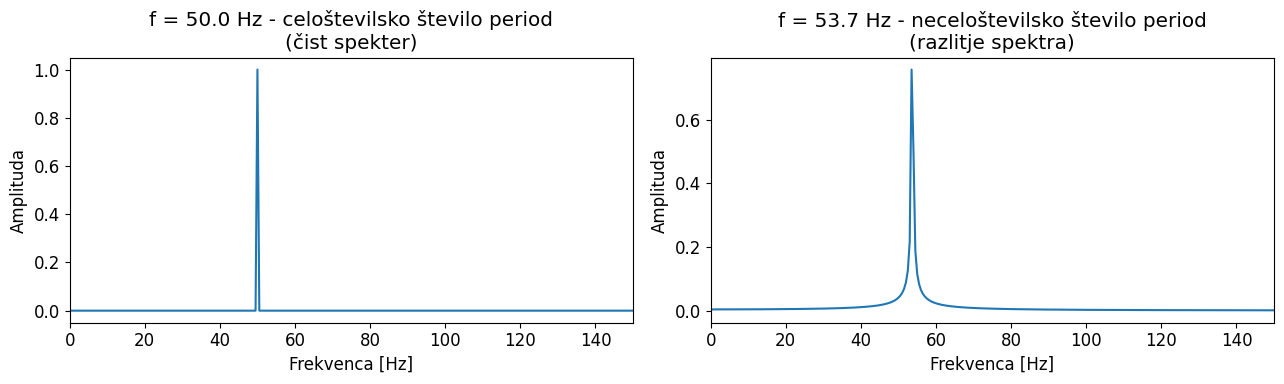

In [34]:
N = 1000
fs = 500.0
t = np.arange(N) / fs

f_celo   = 50.0    # celoštevilsko število period v oknu
f_necelo = 53.7    # neceloštevilsko število period

freq, F_celo   = rfft_enostranski(np.sin(2 * np.pi * f_celo   * t), fs)
_,     F_necelo = rfft_enostranski(np.sin(2 * np.pi * f_necelo * t), fs)

fig, axes = plt.subplots(1, 2)
ax_spekter(axes[0], freq, np.abs(F_celo),
           title=f'f = {f_celo} Hz - celoštevilsko število period\n(čist spekter)',
           xlim=[0, 150], stem=False)
ax_spekter(axes[1], freq, np.abs(F_necelo),
           title=f'f = {f_necelo} Hz - neceloštevilsko število period\n(razlitje spektra)',
           xlim=[0, 150], stem=False)
plt.tight_layout()
plt.show()


---
## 4. del: Amplitudni in fazni spekter

Rezultat DFT pri vsaki frekvenci $k$ je **kompleksno število**. Iz njega preberemo dve fizikalni količini:

- **Amplitudni spekter** (`np.abs(F)`): pove, **koliko** posamezne frekvence je v signalu prisotne.
- **Fazni spekter** (`np.angle(F)`): pove, **kdaj** posamezna komponenta doseže vrh glede na $t = 0$ - torej njen časovni zamik.


### Faza čistega sinusa

Sinus je realna, liha funkcija, zato pričakujemo fazo $-90°$ pri $f_0$ (ali $+90°$ pri $-f_0$). 

**Povsod drugje**, kjer je amplituda nič, faza ni določena. V praksi vidimo floating-point zaokrožitvene napake na ravni $\approx 10^{-16}$. 

Faza je fizikalno smiselna **le tam, kjer je amplituda znatna**.

:::{admonition} Primer - Fazni spekter čistega sinusa: signal in šum zaokrožitvenih napak
:class: seealso

Prikažemo amplitudni in fazni spekter čistega sinusa. Opazujemo fazo pri $f_0$ in interpretiramo navidezno »naključne« faze pri vseh ostalih frekvencah.
:::

In [35]:
N = 500
fs = 1000.0
f0 = 50.0
t = np.arange(N) / fs

In [36]:
sig = np.sin(2 * np.pi * f0 * t)
freq, F = rfft_enostranski(sig, fs)

idx_f0 = np.argmin(np.abs(freq - f0))
print(f"Faza pri f0 = {f0} Hz: {np.rad2deg(np.angle(F[idx_f0])):.2f}° (pričakovano: -90°)")
print(f"Amplituda pri f0: {np.abs(F[idx_f0]):.4f} (pričakovano: 1.0)")

Faza pri f0 = 50.0 Hz: -90.00° (pričakovano: -90°)
Amplituda pri f0: 1.0000 (pričakovano: 1.0)


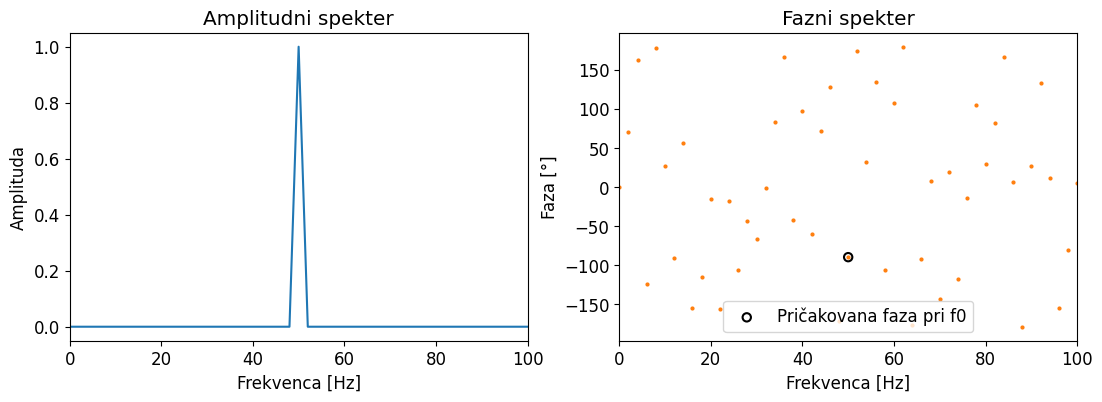

In [37]:
fig, axes = plt.subplots(1, 2)
ax_spekter(axes[0], freq, np.abs(F), title='Amplitudni spekter', stem=False)
ax_faza(axes[1], freq, F, title='Fazni spekter')
axes[1].scatter(f0, -90, facecolors='none', edgecolors='k', linewidths=1.5,
            label='Pričakovana faza pri f0')

axes[0].set_xlim(0, 100)
axes[1].set_xlim(0, 100)
axes[1].legend();

### 4.2 Faza kot časovni zamik

Faza pri frekvenci $f$ neposredno kodira časovni zamik tiste harmonične komponente. Ključna praktična posledica **lastnosti časovnega zamika**: zamik signala v času **ne spremeni amplitudnega spektra** - spremeni le fazni spekter, sorazmerno z zamikom in frekvenco. 

Dve meritvi istega signala z različnim zamikom imata torej enak amplitudni spekter, a različna fazna spektra.

:::{admonition} Primer 4.2 - Časovni zamik in njegov vpliv na fazni spekter
:class: seealso

Isti sinus zamaknemo za različne vrednosti $t_0$ in opazujemo, da se amplitudni spekter ne spremeni, faza pri $f_0$ pa se linearno premakne.
:::

In [38]:
N = 500
fs = 1000.0
f0 = 50.0
t = np.arange(N) / fs
zamiki = [0.0, 0.002, 0.005]   # sekunde

In [39]:
# Za vsak zamik: izračunamo signal in spekter
rezultati = []
for zamik in zamiki:
    sig = np.sin(2 * np.pi * f0 * (t - zamik))
    freq, F = rfft_enostranski(sig, fs)
    rezultati.append((zamik, freq, F))


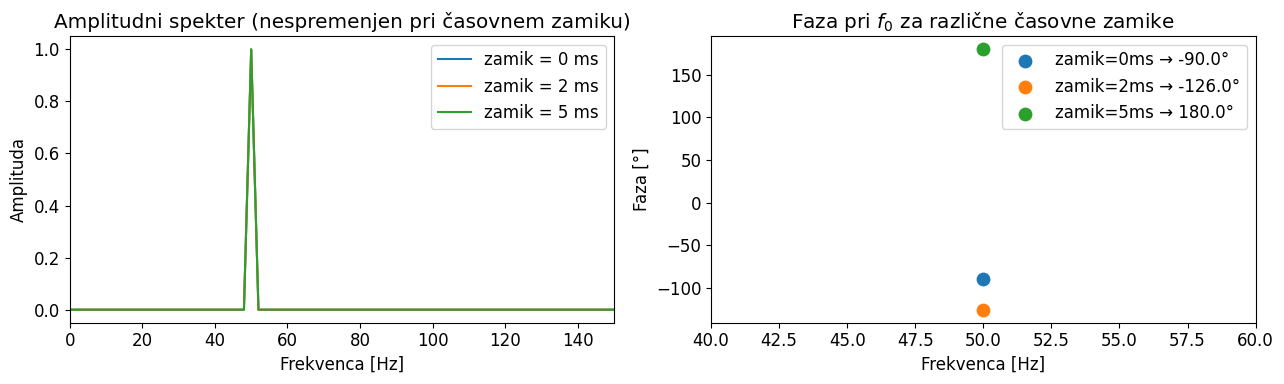

In [40]:
fig, axes = plt.subplots(1, 2)
for zamik, freq, F in rezultati:
    idx = np.argmin(np.abs(freq - f0))
    faza_f0 = np.degrees(np.angle(F[idx]))
    axes[0].plot(freq, np.abs(F), label=f'zamik = {zamik*1000:.0f} ms')
    axes[1].scatter(freq[idx], faza_f0, s=80,
                    label=f'zamik={zamik*1000:.0f}ms → {faza_f0:.1f}°')
ax_spekter(axes[0], title='Amplitudni spekter (nespremenjen pri časovnem zamiku)', xlim=[0, 150])
ax_faza(axes[1], title='Faza pri $f_0$ za različne časovne zamike', xlim=[f0 * 0.8, f0 * 1.2])
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

---
## 5. del: Vloga faze v strukturi signala

:::{note}
**Dva signala sta lahko imata enaka amplitudna spektra, a sta v časovni domeni popolnoma različna** - ker se razlikujeta v faznih spektrih.

- Amplitudni spekter pove *katere* frekvence so prisotne.
- Fazni spekter pove *kako so organizirane v času*.
:::

:::{admonition} Primer 5.1 - Enak amplitudni spekter, različna faza: dve harmonični komponenti
:class: seealso

Sestavimo štiri signale z enakima $f_1$ in $f_2$ ter enakima amplitudama, a različnimi faznimi kombinacijami. Amplitudni spekter je v vseh primerih enak, časovne oblike pa so med seboj povsem različne.
:::

In [41]:
N = 1024
fs = 1000.0
t = np.arange(N) / fs
f1, f2 = 50.0, 120.0
A1, A2 = 1.0, 0.7

fazne_kombinacije = [
    (0,   0,   'Oba začneta pri 0° - poravnana'),
    (0,   180, 'f₂ zamaknjen za 180° - nasprotna faza pri t=0'),
    (45,  135, 'Poljubna fazna razlika'),
]

sigs = [A1 * np.sin(2*np.pi*f1*t + np.radians(faz1))
      + A2 * np.sin(2*np.pi*f2*t + np.radians(faz2))
        for faz1, faz2, _ in fazne_kombinacije]

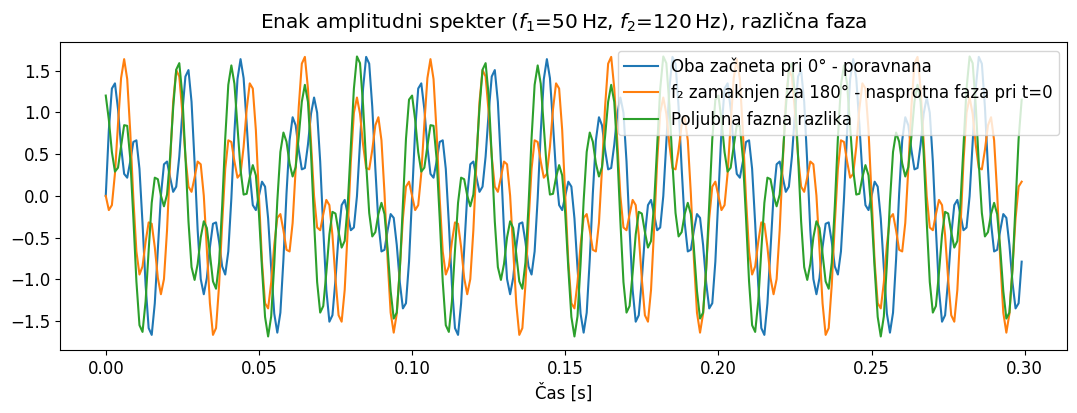

In [42]:
fig, ax = plt.subplots(figsize=(13, 4))
for sig, (_, _, naslov) in zip(sigs, fazne_kombinacije):
    ax.plot(t[:300], sig[:300], label=naslov)
    ax.set_xlabel('Čas [s]')
ax.legend()
plt.title(f'Enak amplitudni spekter ($f_1$={f1:.0f} Hz, $f_2$={f2:.0f} Hz), različna faza', y=1.02);